<a href="https://colab.research.google.com/github/Prameela-04/Google_Trends_Analyis/blob/main/google_search_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pytrends matplotlib pandas seaborn plotly

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq

**Setup Pytrend library and Keyword define**

In [ ]:
pytrends = TrendReq(hl = 'en-US', tz = 360)
keyword = "cloud computing"

**Data Request**

In [ ]:
kw_list = [keyword]

pytrends.build_payload(kw_list, cat=0, timeframe='today 12-m', geo='', gprop='')

data = pytrends.interest_over_time()

data.head()

/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,cloud computing,isPartial
date,,
2025-06-08,22,False
2025-06-15,23,False
2025-06-22,21,False
2025-06-29,18,False
2025-07-06,18,False


**Country wise interest**

In [ ]:
import time
time.sleep(10) # Increasing delay to further prevent TooManyRequestsError
region_data = pytrends.interest_by_region()

# Sort values based on keyword search interest
region_data = region_data.sort_values(
    by=keyword,
    ascending=False
).head(15)

/tmp/ipykernel_3136/1621060839.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




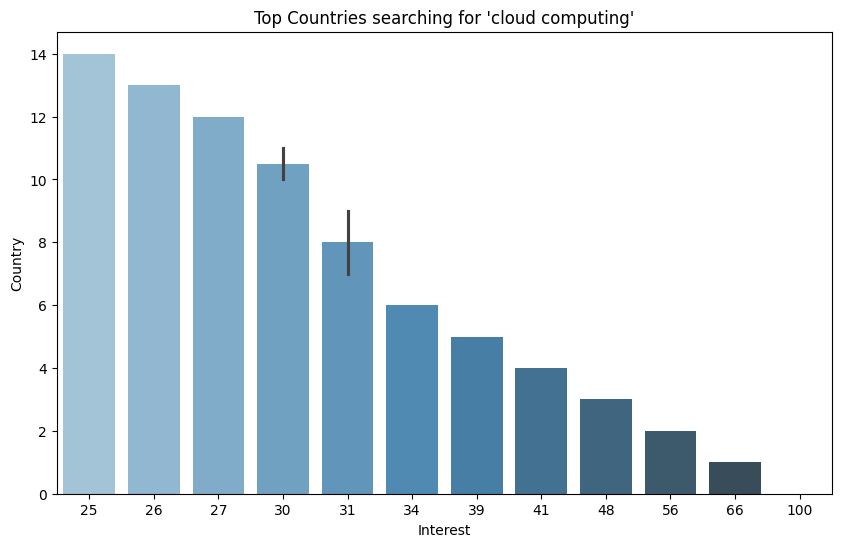

In [ ]:
# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x=region_data[keyword],
    y=region_data.index,
    palette="Blues_d"
)

plt.title(f"Top Countries searching for '{keyword}'")
plt.xlabel("Interest")
plt.ylabel("Country")

plt.show()

**World Map**

In [ ]:
import plotly.io as pio

pio.renderers.default = "colab"

In [ ]:
import plotly.express as px

fig = px.choropleth(
    region_data,
    locations='geoName',
    locationmode='country names',
    color=keyword,
    hover_name='geoName',
    title=f"Search Interest for '{keyword}' by Country",
    color_continuous_scale='Blues'
)

fig.show()

**Time Wise Interset**

In [ ]:
time_df = pytrends.interest_over_time()

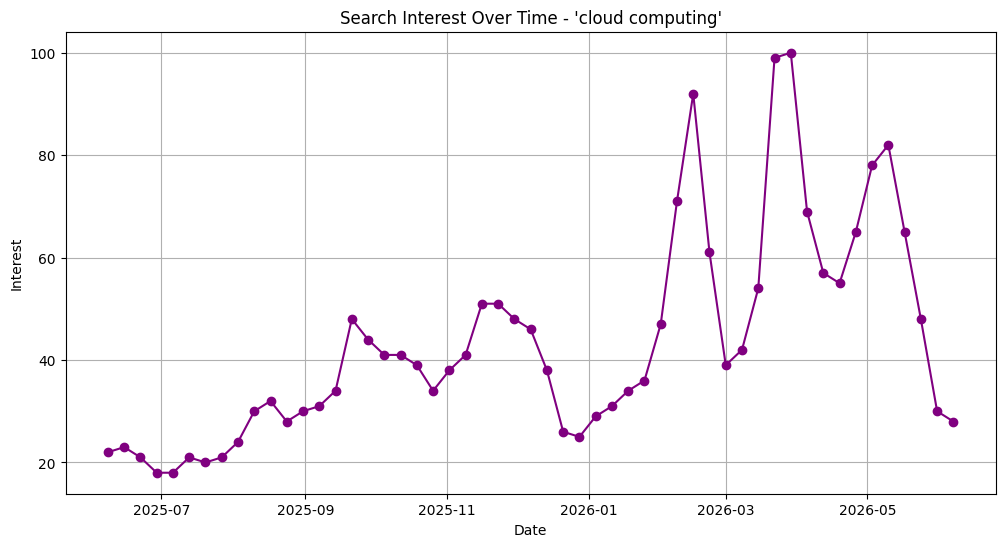

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    time_df.index,
    time_df[keyword],
    marker='o',
    color='purple'
)

plt.title(f"Search Interest Over Time - '{keyword}'")
plt.xlabel("Date")
plt.ylabel("Interest")

plt.grid(True)


**Multiple Keywords Compare**

/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



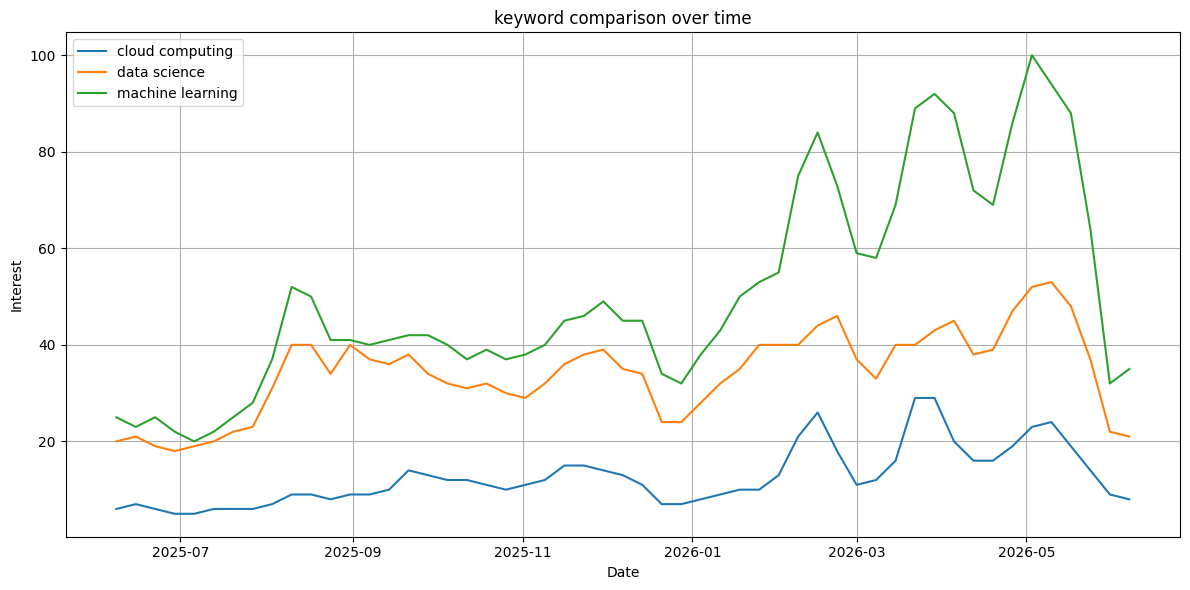

In [ ]:
from pytrends.request import TrendReq
import matplotlib.pyplot as plt

# Connect to Google Trends
pytrends = TrendReq(hl='en-US', tz=360)

# Keywords list
kw_list = ["cloud computing", "data science", "machine learning"]

# Build payload
pytrends.build_payload(
    kw_list,
    cat=0,
    timeframe='today 12-m',
    geo='',
    gprop=''
)

# Get interest over time data
compare_df = pytrends.interest_over_time()

# Plot graph
plt.figure(figsize=(12, 6))

for kw in kw_list:
    plt.plot(compare_df.index, compare_df[kw], label=kw)

plt.title("keyword comparison over time")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()